# Plots dos casos do artigo — não-classicalidade, $\langle Z \rangle$ e $\langle N \rangle$

Este notebook carrega a saída gerada por `run_article_all_cases_simple.py`.

Nesta versão:

- **não há plot de superfície/heatmap**;
- **não há plot de variância**;
- cada caso é plotado em **três painéis empilhados**:
  1. não-classicalidade principal do caso;
  2. valor esperado $\langle Z \rangle$;
  3. valor esperado $\langle N \rangle$.

A estrutura continua usando os arquivos salvos pelo script principal:

```text
const_aberto.npy
var_aberto.npy
*_observables.csv
t.npy
scan_points_used.csv
summary.csv
```


In [1]:
import os
import glob
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (8, 8),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 11,
})

## 1. Escolha da pasta de resultados

Por padrão, o notebook pega automaticamente a pasta mais recente em:

```text
results/article_all_cases/article_all_cases*
```

Para fixar uma execução específica, troque `ROOT = latest_root()` por algo como:

```python
ROOT = "results/article_all_cases/article_all_cases1"
```


In [2]:
def latest_root(base="results/article_all_cases"):
    folders = sorted(glob.glob(os.path.join(base, "article_all_cases*")))
    if not folders:
        raise FileNotFoundError(
            "Não encontrei resultados. Rode primeiro: python run_article_all_cases_simple.py"
        )
    return folders[-1]

ROOT = latest_root()
print("ROOT =", ROOT)

case_map = pd.read_csv(os.path.join(ROOT, "case_map.csv"))
case_map

ROOT = results/article_all_cases/article_all_cases2


,case_id,article_fig,resource,state_kind,coupling,scan_name,scan_display_name,fixed_args,tmax,metric_label,case_dir
0,fig1_coherence_gauss_epsilon,Fig. 1,coherence,coherence,gauss,epsilon,zeta,"{""T"": 25.0, ""sigma"": -1.0}",50.0,C_q(t),fig1_coherence_gauss_epsilon
1,fig2_coherence_gauss_T,Fig. 2,coherence,coherence,gauss,T,T,"{""epsilon"": 8.0, ""sigma"": -1.0}",50.0,C_q(t),fig2_coherence_gauss_T
2,fig3_coherence_cos_omega,Fig. 3,coherence,coherence,cos,w,omega_units,"{""phi"": 0.0}",50.0,C_q(t),fig3_coherence_cos_omega
3,magic_gauss_epsilon,Magic / Eq. 9 + Fig. 1 parameters,magic,magic,gauss,epsilon,zeta,"{""T"": 25.0, ""sigma"": -1.0}",50.0,M_2(t),magic_gauss_epsilon
4,magic_gauss_T,Magic / Eq. 9 + Fig. 2 parameters,magic,magic,gauss,T,T,"{""epsilon"": 8.0, ""sigma"": -1.0}",50.0,M_2(t),magic_gauss_T
5,magic_cos_omega,Magic / Eq. 9 + Fig. 3 parameters,magic,magic,cos,w,omega_units,"{""phi"": 0.0}",50.0,M_2(t),magic_cos_omega
6,fig4_wigner_gauss_epsilon,Fig. 4,wigner,wigner,gauss,epsilon,zeta,"{""T"": 7.5, ""sigma"": -1.0}",15.0,N_W(t),fig4_wigner_gauss_epsilon
7,fig5_wigner_gauss_T,Fig. 5,wigner,wigner,gauss,T,T,"{""epsilon"": 2.4, ""sigma"": -1.0}",15.0,N_W(t),fig5_wigner_gauss_T
8,fig6_wigner_cos_omega,Fig. 6,wigner,wigner,cos,w,omega,"{""phi"": 0.0}",15.0,N_W(t),fig6_wigner_cos_omega
9,fig7_entanglement_gauss_epsilon,Fig. 7,entanglement,entanglement,gauss,epsilon,zeta,"{""T"": 25.0, ""sigma"": -1.0}",50.0,E_N(t),fig7_entanglement_gauss_epsilon


## 2. Funções auxiliares

A função principal aqui é `plot_case_stacked(case_id)`, que monta uma figura com:

1. não-classicalidade;
2. $\langle Z \rangle$;
3. $\langle N \rangle$.

Ela plota junto o caso constante aberto e os três casos variáveis: `min`, `av` e `max`.


In [3]:
def case_dir(case_id):
    return os.path.join(ROOT, case_id)


def load_case(case_id):
    folder = case_dir(case_id)
    with open(os.path.join(folder, "case_metadata.json"), "r", encoding="utf-8") as f:
        meta = json.load(f)

    data = {
        "folder": folder,
        "meta": meta,
        "t": np.load(os.path.join(folder, "t.npy")),
        "const_aberto": np.load(os.path.join(folder, "const_aberto.npy")),
        "var_aberto": np.load(os.path.join(folder, "var_aberto.npy")),
        "scan": pd.read_csv(os.path.join(folder, "scan_points_used.csv")),
        "summary": pd.read_csv(os.path.join(folder, "summary.csv")),
    }
    return data


def load_observables(case_id, label):
    path = os.path.join(case_dir(case_id), f"{label}_observables.csv")
    if not os.path.exists(path):
        labels = ["const_aberto", "var_aberto_min", "var_aberto_av", "var_aberto_max"]
        raise FileNotFoundError(f"Não achei {path}. Labels esperados: {labels}")
    return pd.read_csv(path)


def safe_log_limits(arrays, floor=1e-12):
    vals = []
    for arr in arrays:
        arr = np.asarray(arr, dtype=float)
        vals.extend(arr[np.isfinite(arr) & (arr > 0)].tolist())
    if len(vals) == 0:
        return floor, 1.0
    ymin = max(floor, min(vals) * 0.7)
    ymax = max(vals) * 1.3
    return ymin, ymax


def labels_for_case(data):
    labels = [("const_aberto", "const. aberto", data["const_aberto"])]
    for i, row in data["scan"].iterrows():
        label = f"var_aberto_{row['label']}"
        pretty = f"{row['label']} = {row['display_value']:.4g}"
        labels.append((label, pretty, data["var_aberto"][i]))
    return labels


def use_log_for_metric(resource):
    return resource in {"coherence", "entanglement"}


def plot_case_stacked(case_id, save=True):
    data = load_case(case_id)
    meta = data["meta"]
    t = data["t"]
    resource = meta["resource"]
    metric_label = meta.get("metric_label", "non-classicality")
    curves = labels_for_case(data)

    fig, axes = plt.subplots(
        3,
        1,
        figsize=(9.0, 8.2),
        sharex=True,
        constrained_layout=True,
    )

    # --------------------------
    # 1) Não-classicalidade
    # --------------------------
    ax = axes[0]
    metric_arrays = []
    for label, pretty, y in curves:
        metric_arrays.append(y)
        if label == "const_aberto":
            ax.plot(t, y, lw=2.2, linestyle="--", label=pretty)
        else:
            ax.plot(t, y, lw=1.9, label=pretty)

    if use_log_for_metric(resource):
        ax.set_yscale("log")
        ax.set_ylim(*safe_log_limits(metric_arrays))

    ax.set_ylabel(metric_label)
    ax.set_title(
        f"{meta['article_fig']} | {resource} | {meta['coupling']} | {meta['scan_display_name']}"
    )
    ax.legend(fontsize=8, ncol=2)

    # --------------------------
    # 2) <Z>
    # --------------------------
    ax = axes[1]
    for label, pretty, _ in curves:
        df = load_observables(case_id, label)
        if label == "const_aberto":
            ax.plot(df["time"], df["expect_Z"], lw=2.2, linestyle="--", label=pretty)
        else:
            ax.plot(df["time"], df["expect_Z"], lw=1.9, label=pretty)
    ax.set_ylabel(r"$\langle Z \rangle$")

    # --------------------------
    # 3) <N>
    # --------------------------
    ax = axes[2]
    for label, pretty, _ in curves:
        df = load_observables(case_id, label)
        if label == "const_aberto":
            ax.plot(df["time"], df["expect_N"], lw=2.2, linestyle="--", label=pretty)
        else:
            ax.plot(df["time"], df["expect_N"], lw=1.9, label=pretty)
    ax.set_ylabel(r"$\langle N \rangle$")
    ax.set_xlabel("t")

    if save:
        out = os.path.join(data["folder"], f"plot_stacked_nonclassicality_Z_N_{case_id}.png")
        fig.savefig(out, dpi=220, bbox_inches="tight")
        print("salvo:", out)

    plt.show()


def show_summary(case_id):
    return load_case(case_id)["summary"]

## 3. Coerência atômica

Casos do artigo:

- Fig. 1: gaussiano variando largura/`epsilon`, com $T=25$ e $\sigma=-1$;
- Fig. 2: gaussiano variando $T$, com `epsilon=8` e $\sigma=-1$;
- Fig. 3: cosseno variando $\omega$, com $\phi=0$.

Cada figura abaixo mostra, de cima para baixo: coerência, $\langle Z \rangle$ e $\langle N \rangle$.

salvo: results/article_all_cases/article_all_cases2/fig1_coherence_gauss_epsilon/plot_stacked_nonclassicality_Z_N_fig1_coherence_gauss_epsilon.png


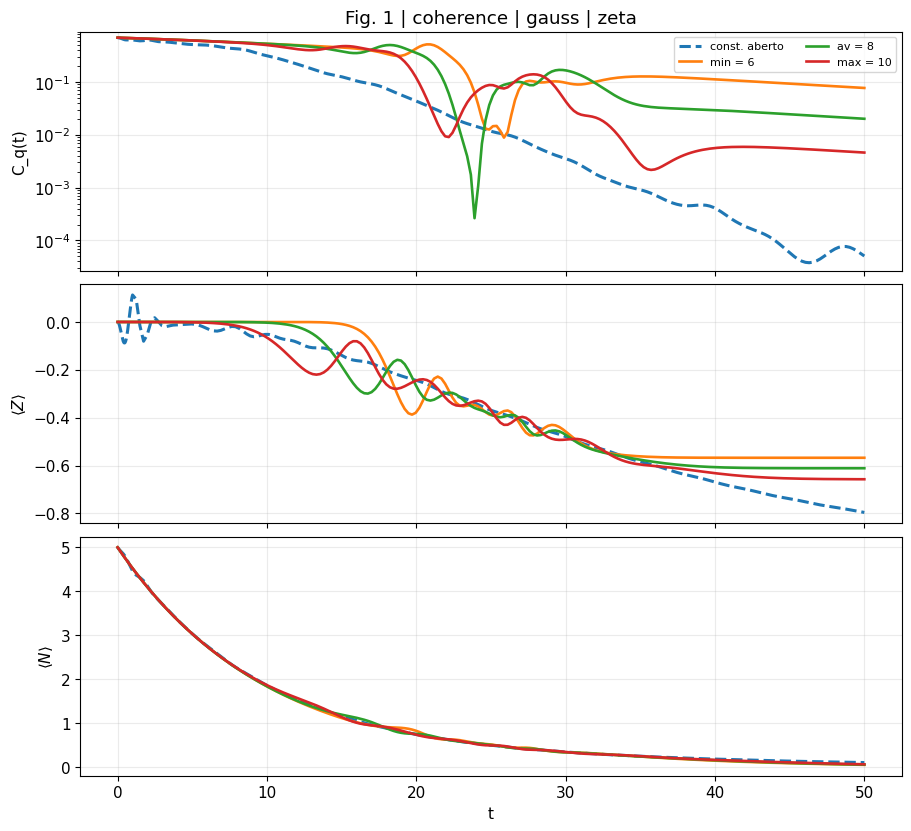

salvo: results/article_all_cases/article_all_cases2/fig2_coherence_gauss_T/plot_stacked_nonclassicality_Z_N_fig2_coherence_gauss_T.png


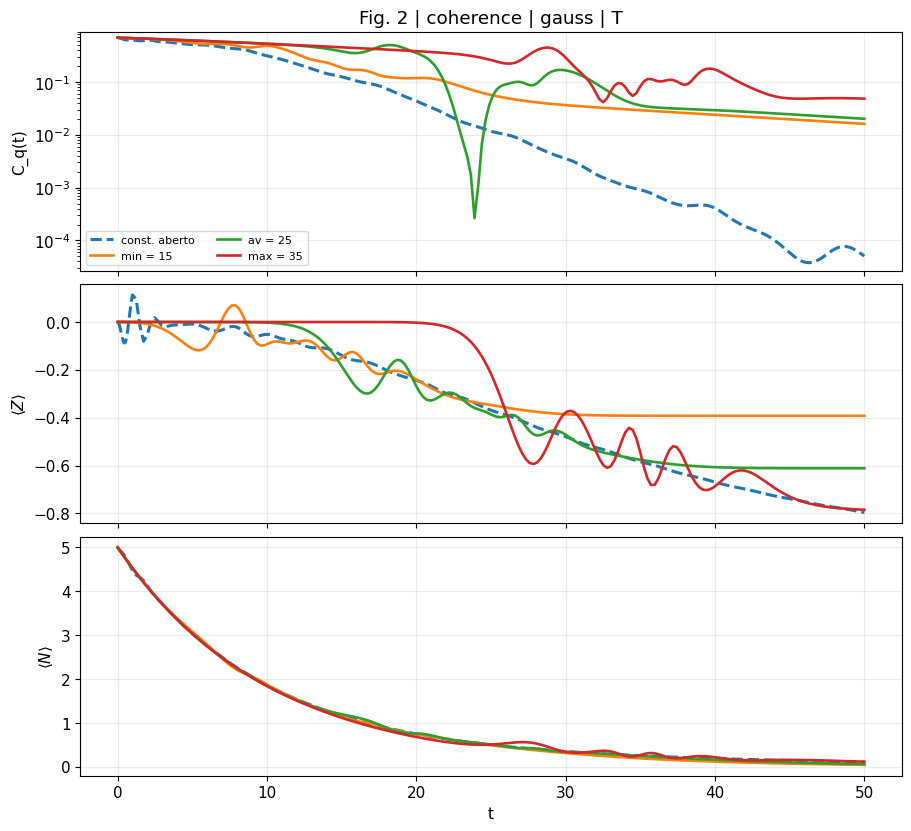

salvo: results/article_all_cases/article_all_cases2/fig3_coherence_cos_omega/plot_stacked_nonclassicality_Z_N_fig3_coherence_cos_omega.png


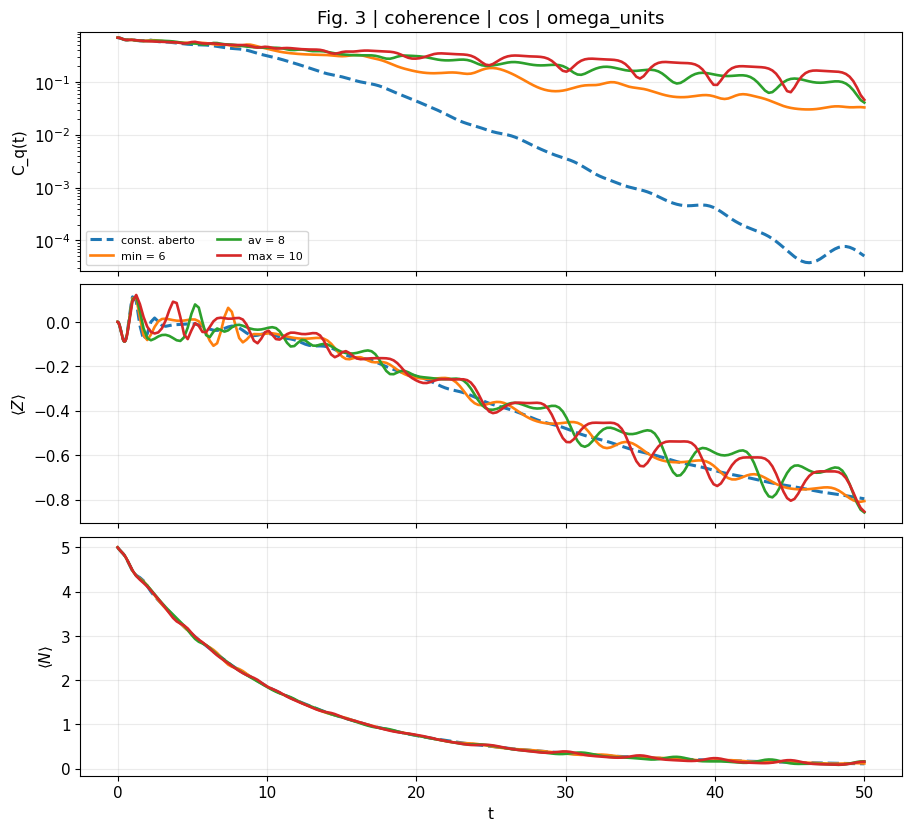

In [4]:
coherence_cases = case_map.query("resource == 'coherence'")["case_id"].tolist()
for cid in coherence_cases:
    plot_case_stacked(cid, save=True)

## 4. Quantum magic atômica

A magic usa a SRE-2 do qubit reduzido. O estado inicial é o estado rico em magic do artigo, com $\cos\theta=1/\sqrt{3}$ e fase $e^{i\pi/4}$.

Cada figura abaixo mostra, de cima para baixo: $M_2(t)$, $\langle Z \rangle$ e $\langle N \rangle$.

salvo: results/article_all_cases/article_all_cases2/magic_gauss_epsilon/plot_stacked_nonclassicality_Z_N_magic_gauss_epsilon.png


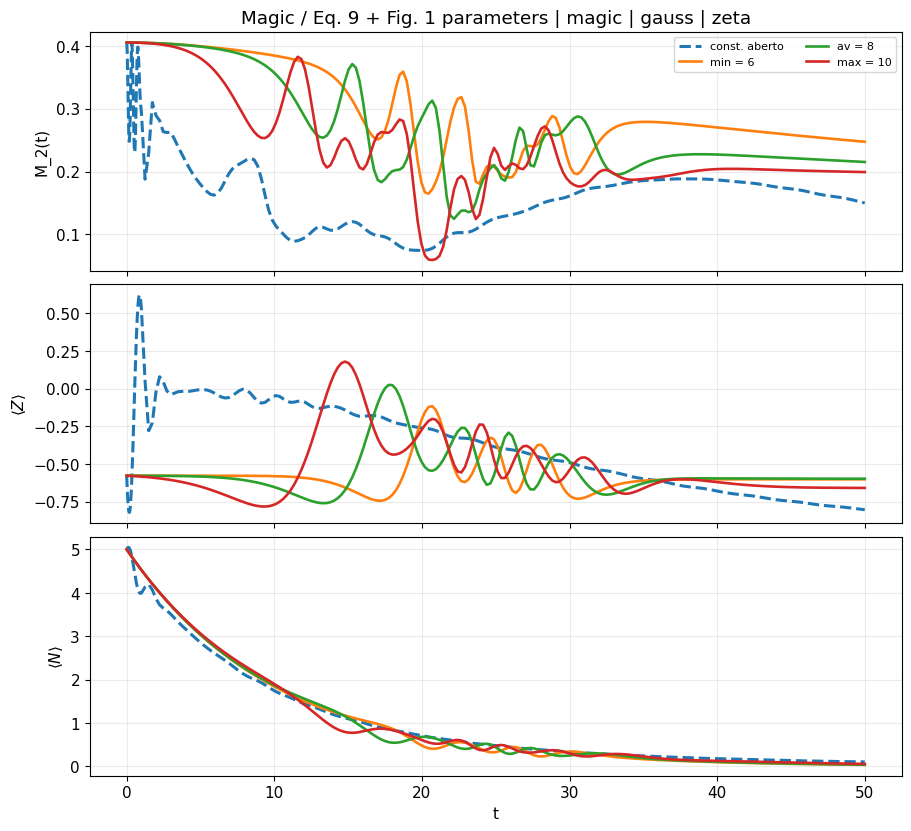

salvo: results/article_all_cases/article_all_cases2/magic_gauss_T/plot_stacked_nonclassicality_Z_N_magic_gauss_T.png


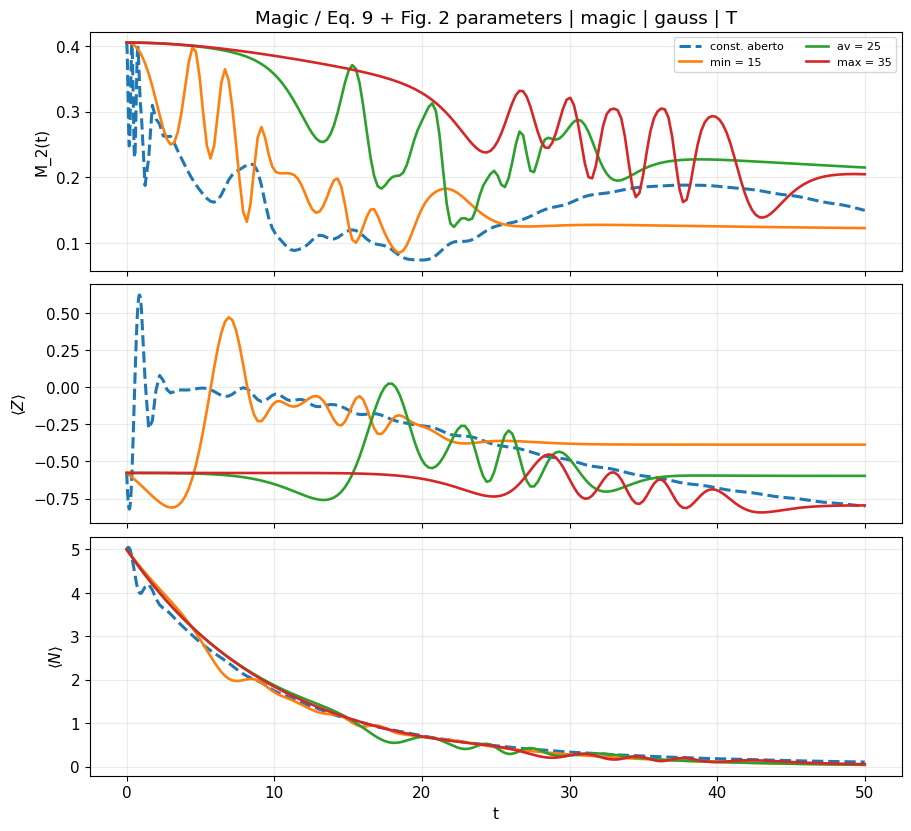

salvo: results/article_all_cases/article_all_cases2/magic_cos_omega/plot_stacked_nonclassicality_Z_N_magic_cos_omega.png


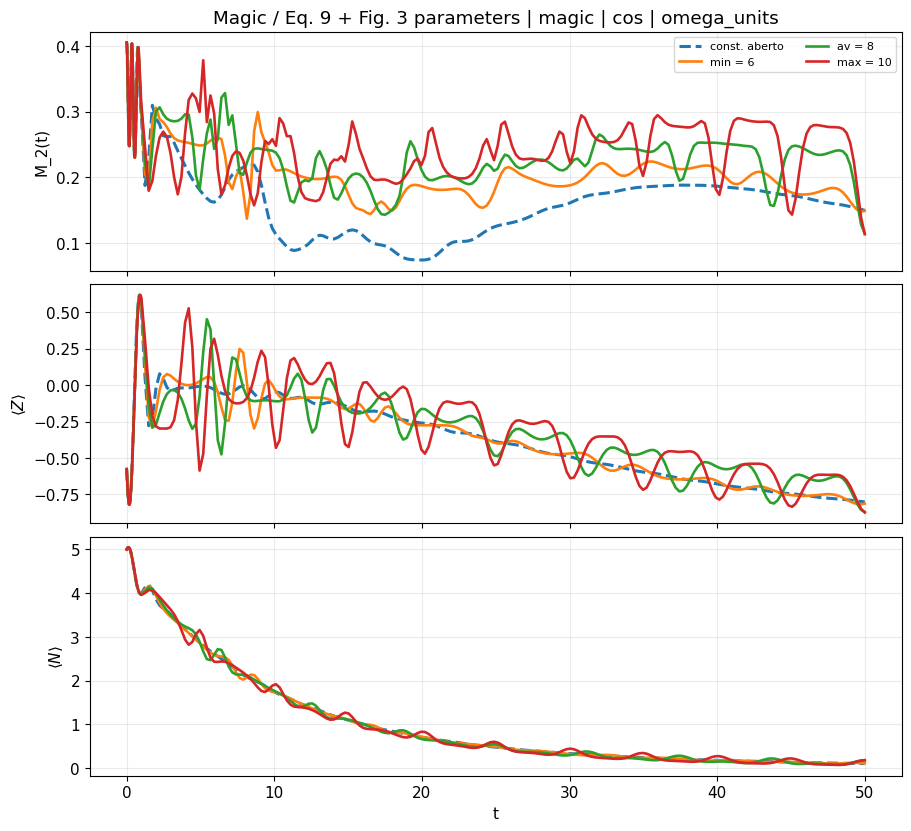

In [5]:
magic_cases = case_map.query("resource == 'magic'")["case_id"].tolist()
for cid in magic_cases:
    plot_case_stacked(cid, save=True)

## 5. Negatividade da Wigner

Casos do artigo:

- Fig. 4: gaussiano variando largura/`epsilon`, com $T=7.5$;
- Fig. 5: gaussiano variando $T$, com `epsilon=2.4`;
- Fig. 6: cosseno variando $\omega$, com $\phi=0$.

Cada figura abaixo mostra, de cima para baixo: negatividade da Wigner, $\langle Z \rangle$ e $\langle N \rangle$.

salvo: results/article_all_cases/article_all_cases2/fig4_wigner_gauss_epsilon/plot_stacked_nonclassicality_Z_N_fig4_wigner_gauss_epsilon.png


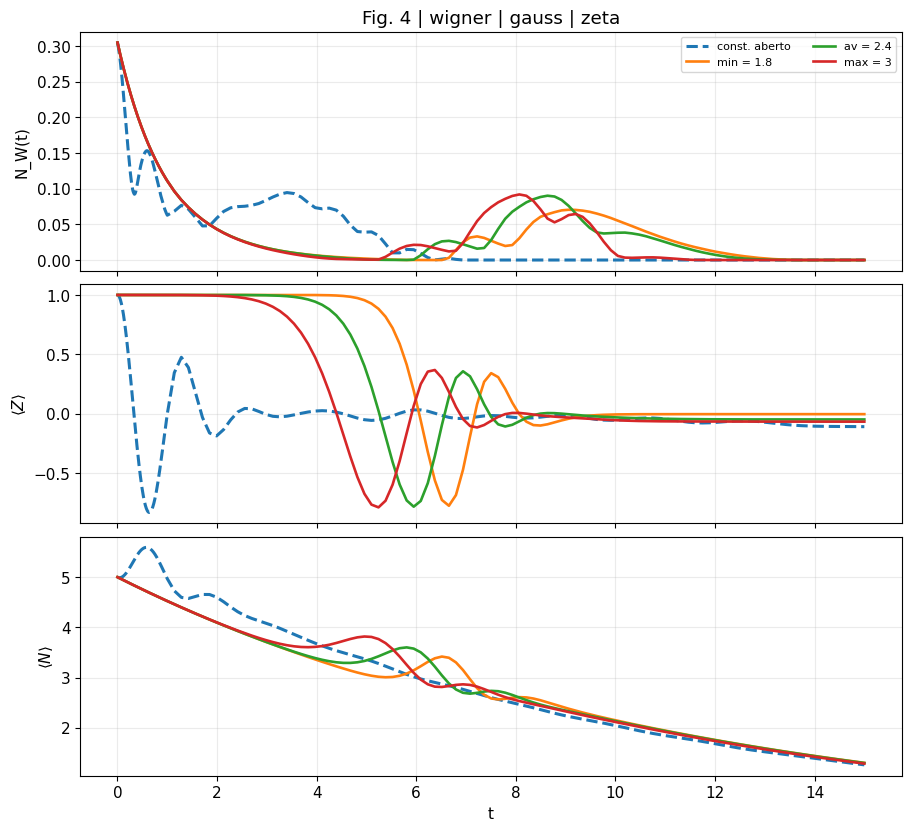

salvo: results/article_all_cases/article_all_cases2/fig5_wigner_gauss_T/plot_stacked_nonclassicality_Z_N_fig5_wigner_gauss_T.png


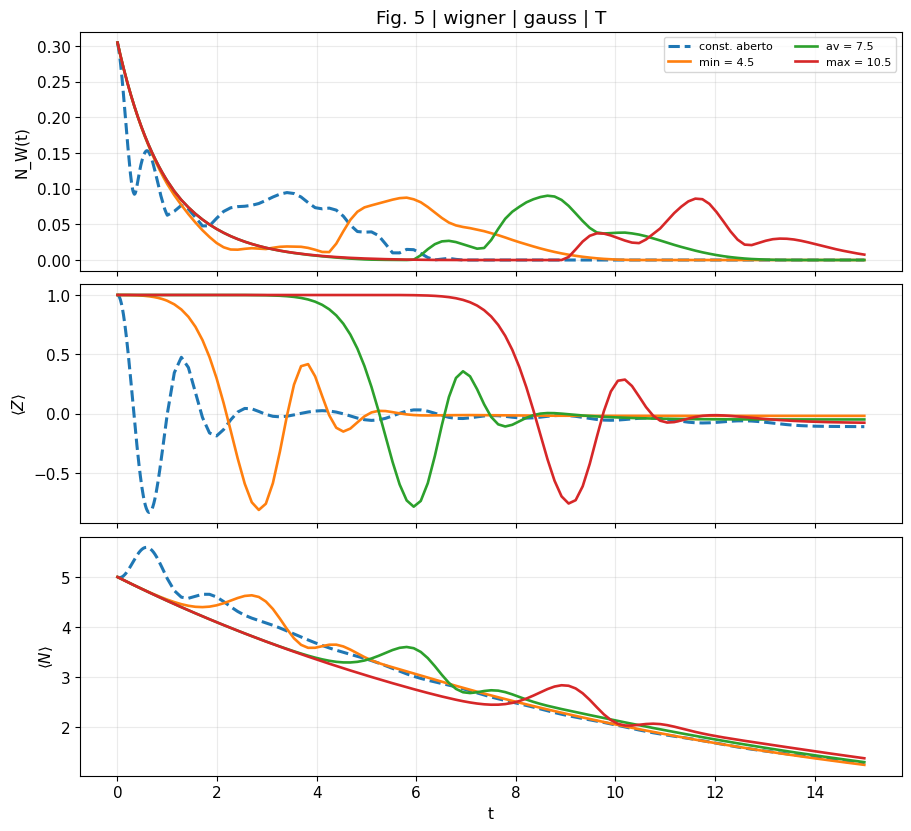

salvo: results/article_all_cases/article_all_cases2/fig6_wigner_cos_omega/plot_stacked_nonclassicality_Z_N_fig6_wigner_cos_omega.png


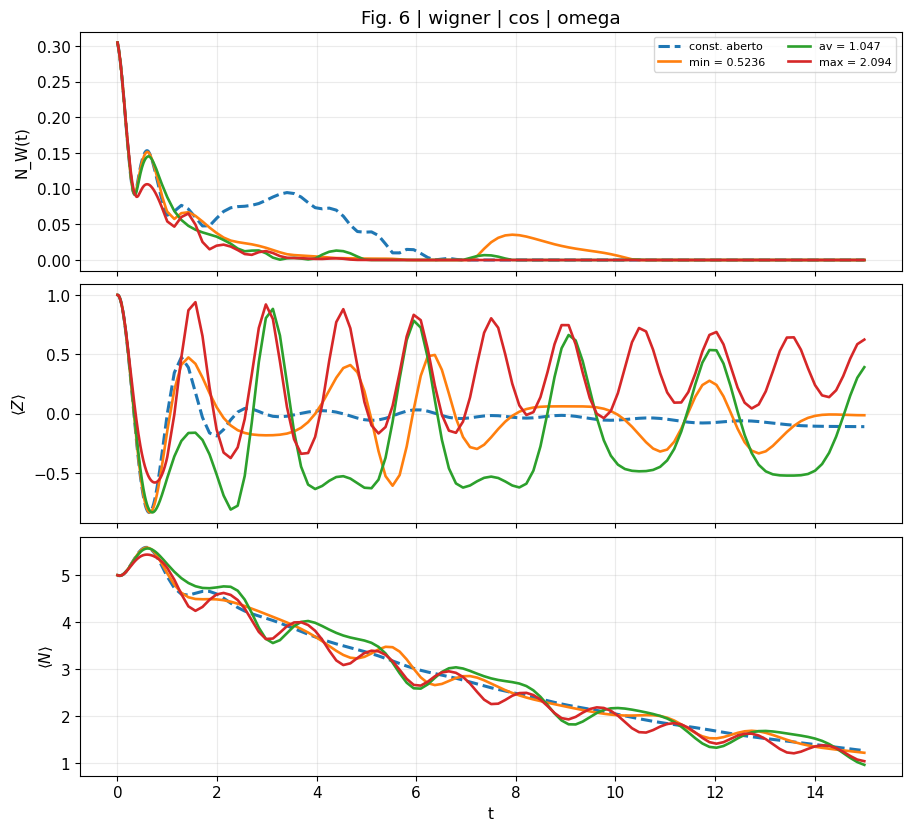

In [6]:
wigner_cases = case_map.query("resource == 'wigner'")["case_id"].tolist()
for cid in wigner_cases:
    plot_case_stacked(cid, save=True)

## 6. Emaranhamento átomo-campo

Casos do artigo:

- Fig. 7: gaussiano variando largura/`epsilon`, com $T=25$;
- Fig. 8: gaussiano variando $T$, com `epsilon=8`;
- Fig. 9: cosseno variando $\omega$, com $\phi=0$.

Cada figura abaixo mostra, de cima para baixo: emaranhamento, $\langle Z \rangle$ e $\langle N \rangle$.

salvo: results/article_all_cases/article_all_cases2/fig7_entanglement_gauss_epsilon/plot_stacked_nonclassicality_Z_N_fig7_entanglement_gauss_epsilon.png


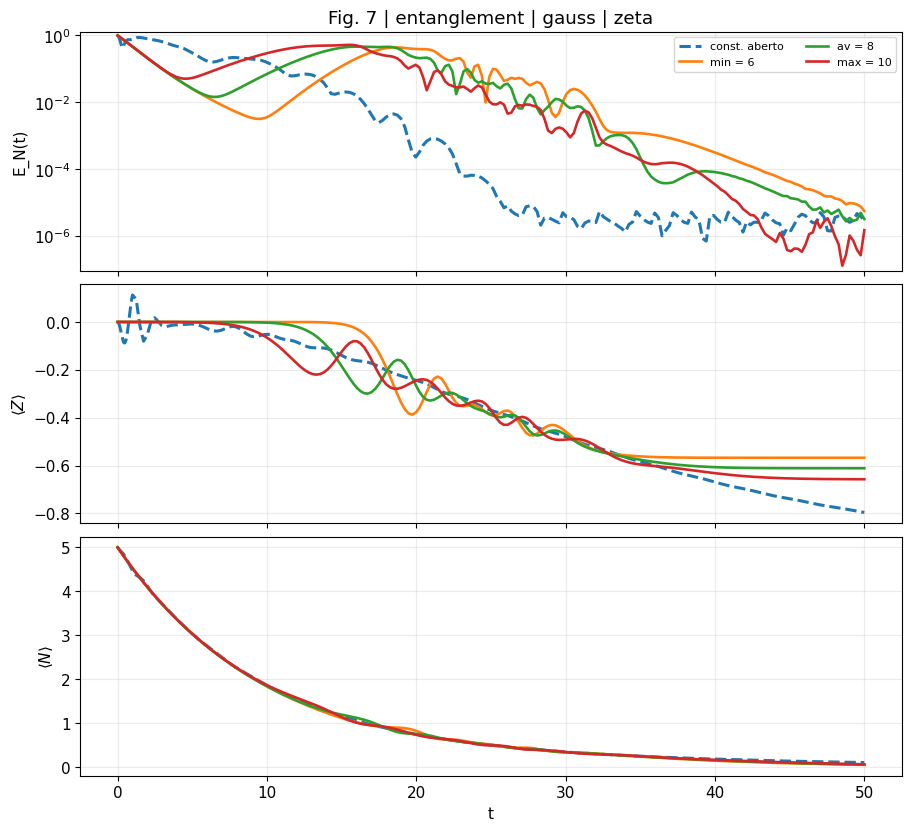

salvo: results/article_all_cases/article_all_cases2/fig8_entanglement_gauss_T/plot_stacked_nonclassicality_Z_N_fig8_entanglement_gauss_T.png


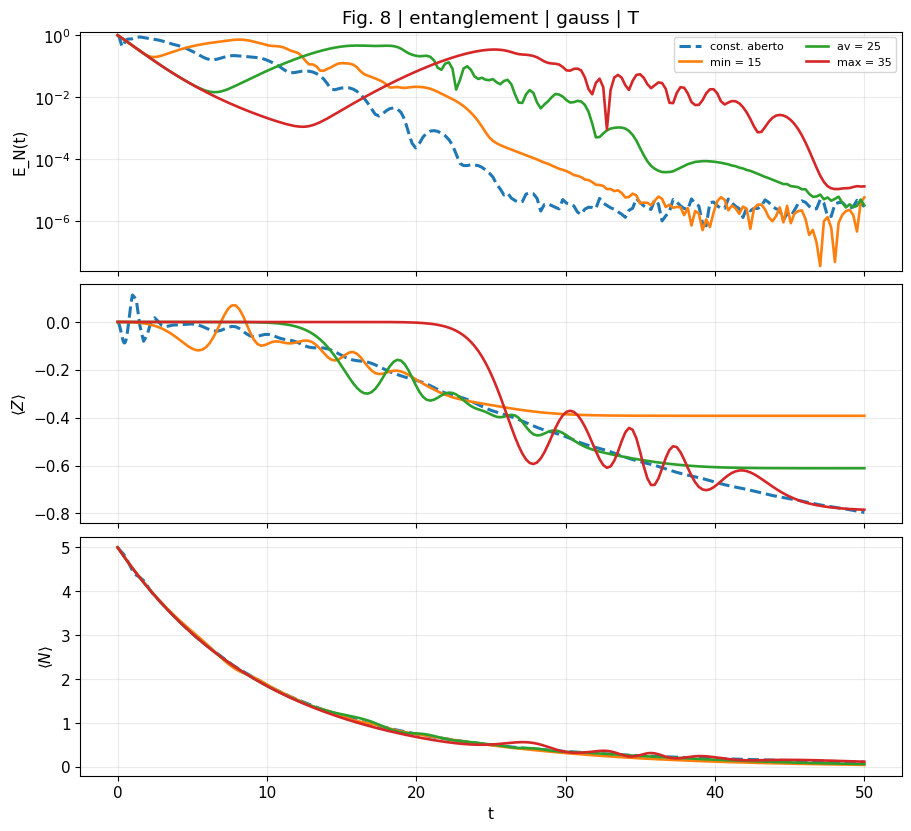

salvo: results/article_all_cases/article_all_cases2/fig9_entanglement_cos_omega/plot_stacked_nonclassicality_Z_N_fig9_entanglement_cos_omega.png


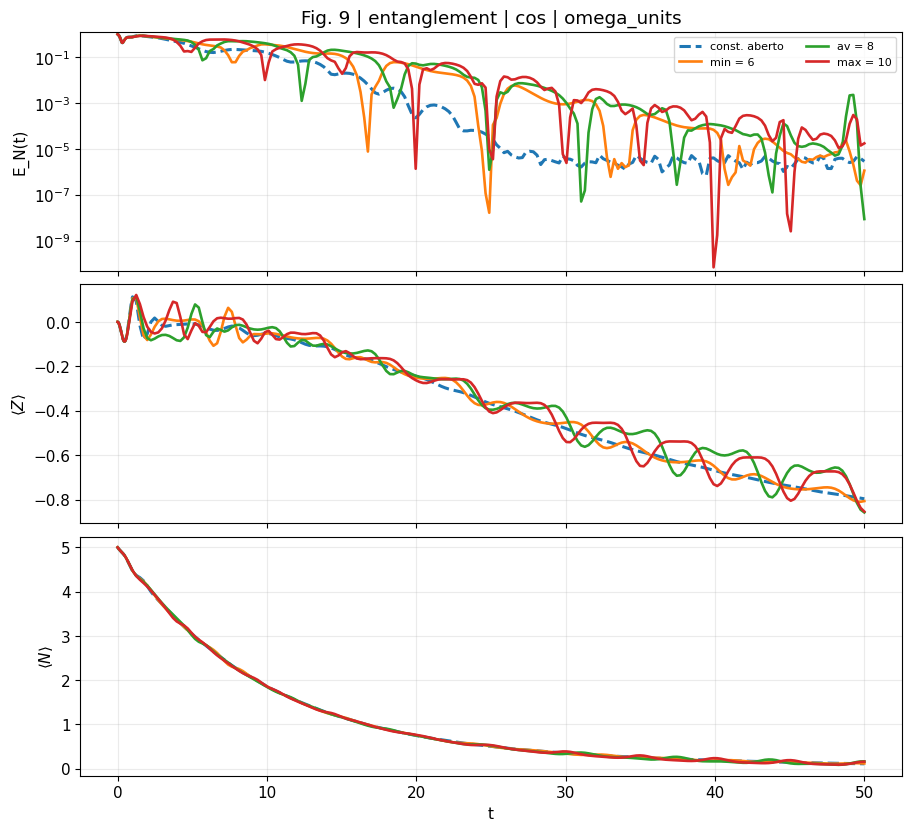

In [7]:
entanglement_cases = case_map.query("resource == 'entanglement'")["case_id"].tolist()
for cid in entanglement_cases:
    plot_case_stacked(cid, save=True)

## 7. Escolher um caso específico

Use esta seção para olhar com mais cuidado um único caso.

Exemplos de `case_id`:

```text
fig1_coherence_gauss_epsilon
fig2_coherence_gauss_T
fig3_coherence_cos_omega
magic_gauss_epsilon
magic_gauss_T
magic_cos_omega
fig4_wigner_gauss_epsilon
fig5_wigner_gauss_T
fig6_wigner_cos_omega
fig7_entanglement_gauss_epsilon
fig8_entanglement_gauss_T
fig9_entanglement_cos_omega
```


salvo: results/article_all_cases/article_all_cases2/fig4_wigner_gauss_epsilon/plot_stacked_nonclassicality_Z_N_fig4_wigner_gauss_epsilon.png


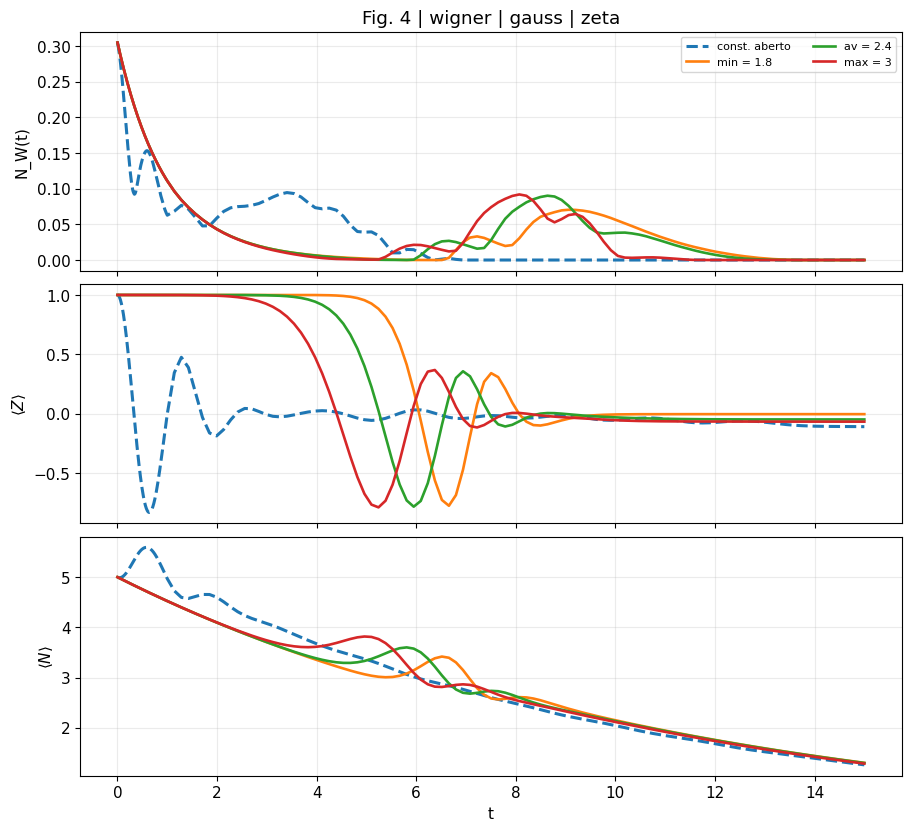

,label,case_id,scan_name,scan_value,display_value,metric_initial,metric_max,metric_mean,metric_final,time_at_max
0,const_aberto,fig4_wigner_gauss_epsilon,const,NaN,NaN,0.304704,0.304704,0.083063,3.724585e-08,0.0
1,var_aberto_min,fig4_wigner_gauss_epsilon,epsilon,1.8,1.8,0.304704,0.304704,0.108336,1.143530e-14,0.0
2,var_aberto_av,fig4_wigner_gauss_epsilon,epsilon,2.4,2.4,0.304704,0.304704,0.108949,1.544209e-12,0.0
3,var_aberto_max,fig4_wigner_gauss_epsilon,epsilon,3.0,3.0,0.304704,0.304704,0.107908,1.877609e-12,0.0


In [8]:
SELECTED_CASE_ID = "fig4_wigner_gauss_epsilon"

plot_case_stacked(SELECTED_CASE_ID, save=True)
show_summary(SELECTED_CASE_ID)